# Tilley’s Algorithm

In this notebook, I implement the Tilley's bundling method for American option pricing.
The content of this notebook is based on a paper "Valuing American Options in a Path Simulation Model" by James A. Tilley.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Parameters

Let $Q$ denote the number of bundles and $P$ the number of paths in each bundle. In the description given in the original paper, the variable $\alpha$ is introduced to determine the values of $P$ and $Q$. Here, however, we first set $Q$ and $P$, and define the total number of samples $R$ as $R = P \times Q$.

In [2]:
time_step = 0.1
terminal_time = 1
time_grid = np.arange(0, terminal_time + time_step, time_step)
num_steps = len(time_grid)

# "Q" is the number of bundles
Q = 30
# "P" is the number of paths in each bundle
P = 50
# total number of samples R = P * Q
num_total_samples = Q * P

initial_stock_price = 100
riskless = 0.03
strike_price = 100

# "sigma" is a volatility term of GBM
sigma = 0.2

# 2. Functions

In the substeps of backward induction below, two indicator functions, `tentative_indicator` and `new_indicator`, appear. To follow the method introduced in the original paper, we define two functions to identify the sharp boundary.

In [3]:
def find_sharp_boundary_position(arr):
    n = len(arr)
    i = 0
    while i < n:
        if arr[i] == 1:
            start_1 = i
            # Measure the length of the consecutive 1s
            while i < n and arr[i] == 1:
                i += 1
            len_1 = i - start_1
            # Find the maximum length of consecutive 0s after this 1s block
            max_0_len = 0
            j = i
            while j < n:
                if arr[j] == 0:
                    start_0 = j
                    while j < n and arr[j] == 0:
                        j += 1
                    len_0 = j - start_0
                    max_0_len = max(max_0_len, len_0)
                else:
                    j += 1
            # Check if the current 1s block is longer than any following 0s block
            if len_1 > max_0_len:
                return start_1
        else:
            i += 1
    return -1  # Return -1 if no 1s block satisfies the condition

def new_indicator_variable(arr):
    # Get the position of the first special 1s block
    pos = find_sharp_boundary_position(arr)
    
    if pos == -1:
        # If no such 1s block exists, return an array of zeros
        return np.zeros_like(arr)
    
    # Create a new array with ones and set all elements to the left of 'pos' to zero
    new_arr = np.ones_like(arr)
    new_arr[:pos] = 0
    return new_arr

In this code, we consider an American call option. The intrinsic value of the option at time $t$ is given by
$$ \max(S(t) - K, 0).$$
Here, K is the strike price. While the strike price could, in principle, vary over time, here we assume it remains constant.

In [4]:
def call_intrinsic_value(price):
    return max(0, price - strike_price)

# 3. Drawing paths

The model for stock price is 1-dimensional GBM;
$$ \frac{dS(t)}{S(t)} = r dt + \sigma dW(t).$$
To draw its path, we use the explicit form of GBM;
$$ S(t) = S(0) \exp \left \{(r - \frac{1}{2} \sigma^2) \ t + \sigma W(t) \right \}.$$

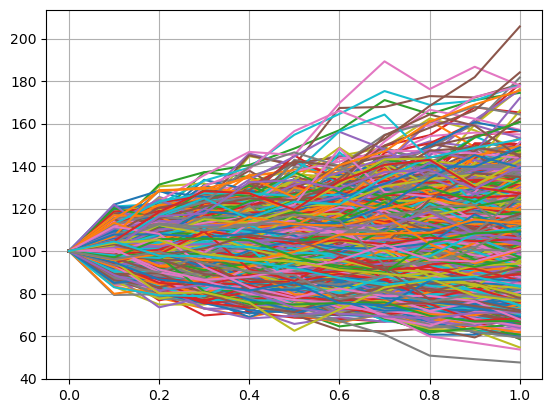

In [5]:
stock_price = np.zeros((num_total_samples, num_steps))
W = np.zeros((num_total_samples, num_steps))
for i in range(num_total_samples):
    for j in range(num_steps-1):
        Z = np.random.normal(loc=0,scale=1)
        W[i][j+1] = W[i][j] + np.sqrt(time_grid[j+1] - time_grid[j]) * Z

for i in range(num_total_samples):
    stock_price[i][0] = initial_stock_price
    for j in range(1,num_steps):
        stock_price[i][j] = initial_stock_price * np.exp((riskless - 1/2 * sigma**2) * time_grid[j] + sigma * W[i][j])

for i in range(num_total_samples):
    plt.plot(time_grid, stock_price[i])
plt.grid(True)
plt.show()

# 4. Backward induction (Identifying the optimal exercise time)

In the backward induction procedure, the continuation value H(k,t) is computed by
$$ H(k,t) = d(k,t) \frac{1}{P} \sum_{\text{all} \ j \ \text{in bundle} \\ \text{containing} \ k} V(j,t+1).$$

In [6]:
sorted_stock_price = np.sort(stock_price, axis=0)
intrinsic_value = np.zeros((num_total_samples, num_steps))

for i in range(num_total_samples):
    for j in range(num_steps):
        intrinsic_value[i][j] = call_intrinsic_value(sorted_stock_price[i][j])

continuation_value = np.zeros((num_total_samples, num_steps))
option_value = np.zeros((num_total_samples, num_steps))
option_value[:,num_steps-1] = intrinsic_value[:,num_steps-1]
tentative_indicator = np.zeros((num_total_samples, num_steps))
new_indicator = np.zeros((num_total_samples, num_steps))

for i in range(num_total_samples):
    if intrinsic_value[i][num_steps-1] > continuation_value[i][num_steps-1]:
        tentative_indicator[i][num_steps-1] = 1
    else:
        tentative_indicator[i][num_steps-1] = 0
    new_indicator[:,num_steps-1] = new_indicator_variable(tentative_indicator[:,num_steps-1])

# Change the line immediately below to: for j in reversed(range(num_steps-1)): when it is possible to exercise the option at epoch 0.
for j in reversed(range(1, num_steps-1)): 
    for i in range(num_total_samples):
        idx = i // P
        x = np.exp(- riskless * time_step) * np.mean(option_value[idx*P:(idx+1)*P,j+1])
        continuation_value[idx*P:(idx+1)*P, j] = np.full(shape=P, fill_value=x, dtype=np.float64)
        if intrinsic_value[i][j] > continuation_value[i][j]:
            tentative_indicator[i][j] = 1
        else:
            tentative_indicator[i][j] = 0
        new_indicator[:,j] = new_indicator_variable(tentative_indicator[:,j])
        if new_indicator[i][j] ==1:
            option_value[i][j] = intrinsic_value[i][j]
        else:
            option_value[i][j] = continuation_value[i][j]

optimal_exercise = np.zeros((num_total_samples, num_steps))
for i in range(num_total_samples):
    j=0
    while j <= num_steps-1:
        if new_indicator[i][j] == 0:
            j +=1
        else:
            optimal_exercise[i][j] = 1
            break

# 5. Computing the estimator

The estimator we aim to obtain is
$$ \text{Estimator} = \frac{1}{R} \sum_{\text{all paths}} \sum_{\text{all epochs}} z(k,t) D(k,t) I(k,t).$$

In [7]:
discount_factor = np.zeros((num_total_samples, num_steps))

for j in range(num_steps):
    x = np.exp(- riskless * time_step * j)
    discount_factor[:,j] = np.full(shape=num_total_samples, fill_value=x, dtype=np.float64)

premium_estimator = 0

for i in range(num_total_samples):
    for j in range(num_steps):
        premium_estimator += optimal_exercise[i][j] * discount_factor[i][j] * intrinsic_value[i][j]

premium_estimator = premium_estimator/num_total_samples
print(premium_estimator)

9.093201398522137


# References

1. James A. Tilley. *Valuing American Options in a Path Simulation Model*. Transactions of the Society of Actuaries. 45. 1993.